<a href="https://colab.research.google.com/github/kananshr13/CSET-343-Ai-in-Healthcare/blob/main/Lab_Experiment_1_CSET_342.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pandas numpy matplotlib scikit-learn wfdb pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
!pip install -q ucimlrepo

In [4]:
from ucimlrepo import fetch_ucirepo

# Fetch UCI Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

# Features and target
X = heart_disease.data.features
y = heart_disease.data.targets

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFirst 5 rows:")
display(X.head())

Feature Shape: (303, 13)
Target Shape: (303, 1)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [5]:
print("Column Names:")
print(X.columns.tolist())

print("\nData Types:")
print(X.dtypes)

print("\nMissing Values:")
print(X.isnull().sum())

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64


In [6]:
df = X.copy()

df["target"] = y.iloc[:, 0]

print("Complete Dataset:")
display(df.head())

Complete Dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [7]:
df = df.replace("?", np.nan)

for column in df.columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df = df.fillna(df.median(numeric_only=True))

print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [8]:
df["target"] = (df["target"] > 0).astype(int)

print(df["target"].value_counts())

target
0    164
1    139
Name: count, dtype: int64


In [9]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [10]:
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


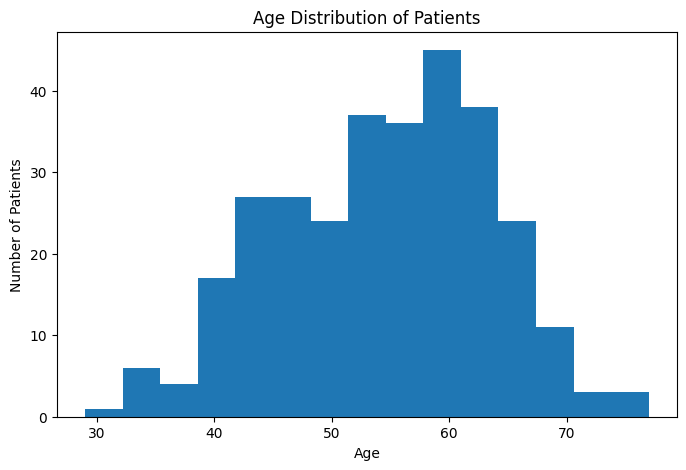

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(df["age"], bins=15)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

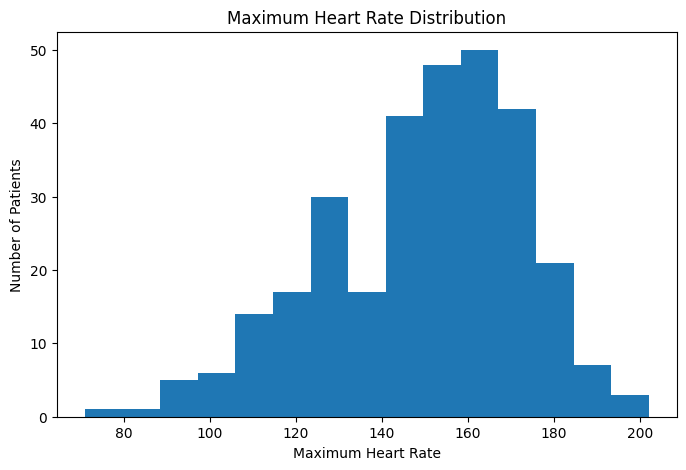

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(df["thalach"], bins=15)

plt.title("Maximum Heart Rate Distribution")
plt.xlabel("Maximum Heart Rate")
plt.ylabel("Number of Patients")

plt.show()

In [13]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8688524590163934


In [14]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



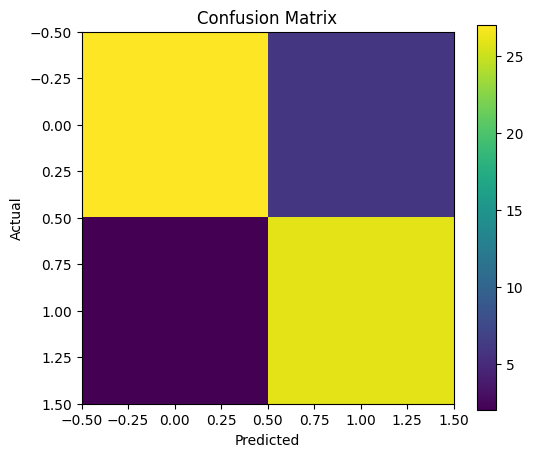

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.show()

In [16]:
clinical_note = """
Patient reports chest pain during physical activity.
The patient experiences shortness of breath and occasional dizziness.
Blood pressure is elevated.
Heart rate is approximately 88 beats per minute.
Further cardiac evaluation is recommended.
"""

with open("clinical_note.txt", "w") as file:
    file.write(clinical_note)

print("Clinical note saved successfully.")

Clinical note saved successfully.


In [17]:
with open("clinical_note.txt", "r") as file:
    note = file.read()

print("Clinical Note:")
print(note)

Clinical Note:

Patient reports chest pain during physical activity.
The patient experiences shortness of breath and occasional dizziness.
Blood pressure is elevated.
Heart rate is approximately 88 beats per minute.
Further cardiac evaluation is recommended.



In [18]:
import re

# Convert to lowercase
text = note.lower()

# Extract words
words = re.findall(r'\b[a-z]+\b', text)

print("Words:")
print(words)

Words:
['patient', 'reports', 'chest', 'pain', 'during', 'physical', 'activity', 'the', 'patient', 'experiences', 'shortness', 'of', 'breath', 'and', 'occasional', 'dizziness', 'blood', 'pressure', 'is', 'elevated', 'heart', 'rate', 'is', 'approximately', 'beats', 'per', 'minute', 'further', 'cardiac', 'evaluation', 'is', 'recommended']


In [19]:
word_frequency = Counter(words)

print("Word Frequency:")
print(word_frequency)

Word Frequency:
Counter({'is': 3, 'patient': 2, 'reports': 1, 'chest': 1, 'pain': 1, 'during': 1, 'physical': 1, 'activity': 1, 'the': 1, 'experiences': 1, 'shortness': 1, 'of': 1, 'breath': 1, 'and': 1, 'occasional': 1, 'dizziness': 1, 'blood': 1, 'pressure': 1, 'elevated': 1, 'heart': 1, 'rate': 1, 'approximately': 1, 'beats': 1, 'per': 1, 'minute': 1, 'further': 1, 'cardiac': 1, 'evaluation': 1, 'recommended': 1})


In [20]:
print("Most Common Terms:")

for word, count in word_frequency.most_common(10):
    print(word, ":", count)

Most Common Terms:
is : 3
patient : 2
reports : 1
chest : 1
pain : 1
during : 1
physical : 1
activity : 1
the : 1
experiences : 1


In [21]:
from google.colab import files

uploaded = files.upload()

Saving CT_Scan_General_Illustration.jpg to CT_Scan_General_Illustration.jpg


In [22]:
image_path = list(uploaded.keys())[0]

image = Image.open(image_path)

print("Image Format:", image.format)
print("Image Size:", image.size)
print("Image Mode:", image.mode)

Image Format: JPEG
Image Size: (907, 895)
Image Mode: RGB


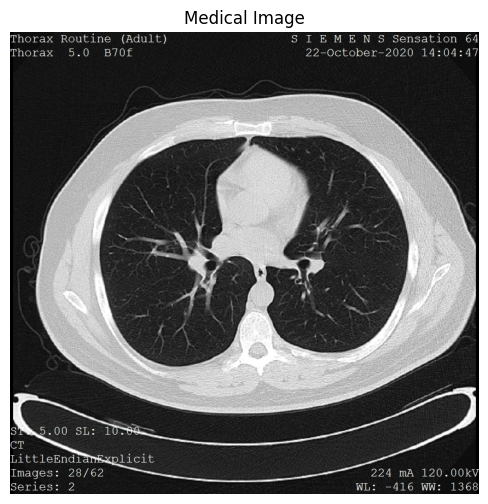

In [23]:
plt.figure(figsize=(8, 6))

plt.imshow(image)
plt.axis("off")

plt.title("Medical Image")

plt.show()

In [24]:
resized_image = image.resize((224, 224))

print("Original Size:", image.size)
print("Resized Size:", resized_image.size)

Original Size: (907, 895)
Resized Size: (224, 224)


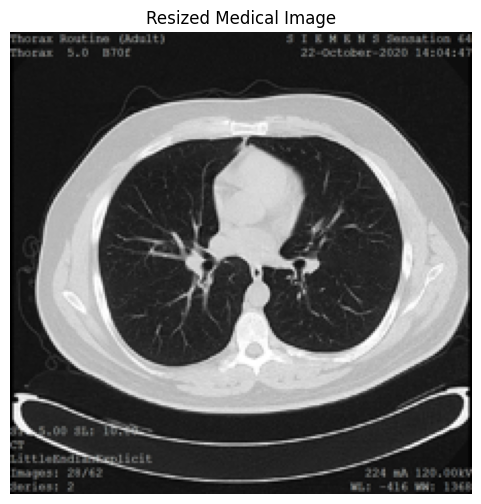

In [25]:
plt.figure(figsize=(6, 6))

plt.imshow(resized_image)
plt.axis("off")

plt.title("Resized Medical Image")

plt.show()

In [26]:
image_array = np.array(resized_image)

print("Image Array Shape:", image_array.shape)
print("Minimum Pixel Value:", image_array.min())
print("Maximum Pixel Value:", image_array.max())

Image Array Shape: (224, 224, 3)
Minimum Pixel Value: 0
Maximum Pixel Value: 255


In [27]:
record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

print("Signal Shape:", record.p_signal.shape)
print("Sampling Frequency:", record.fs)
print("Number of Signals:", record.n_sig)

Signal Shape: (650000, 2)
Sampling Frequency: 360
Number of Signals: 2


In [28]:
print("Signal Names:")
print(record.sig_name)

print("\nSampling Frequency:")
print(record.fs)

Signal Names:
['MLII', 'V5']

Sampling Frequency:
360


In [29]:
annotation = wfdb.rdann(
    "100",
    "atr",
    pn_dir="mitdb"
)

print("Number of Annotations:", len(annotation.sample))

Number of Annotations: 2274


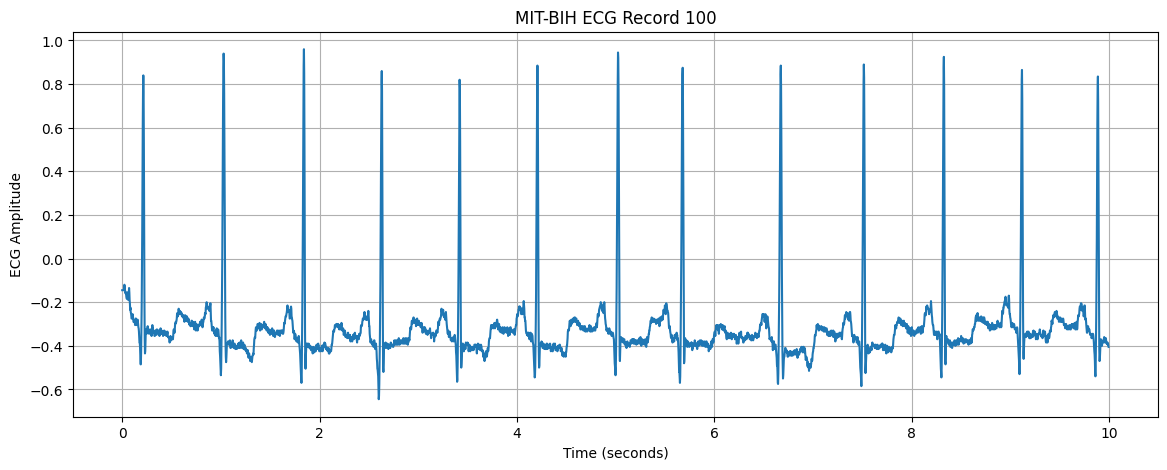

In [30]:
sampling_frequency = record.fs

seconds = 10

samples = int(seconds * sampling_frequency)

signal = record.p_signal[:samples, 0]

time = np.arange(samples) / sampling_frequency

plt.figure(figsize=(14, 5))

plt.plot(time, signal)

plt.title("MIT-BIH ECG Record 100")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")

plt.grid(True)

plt.show()

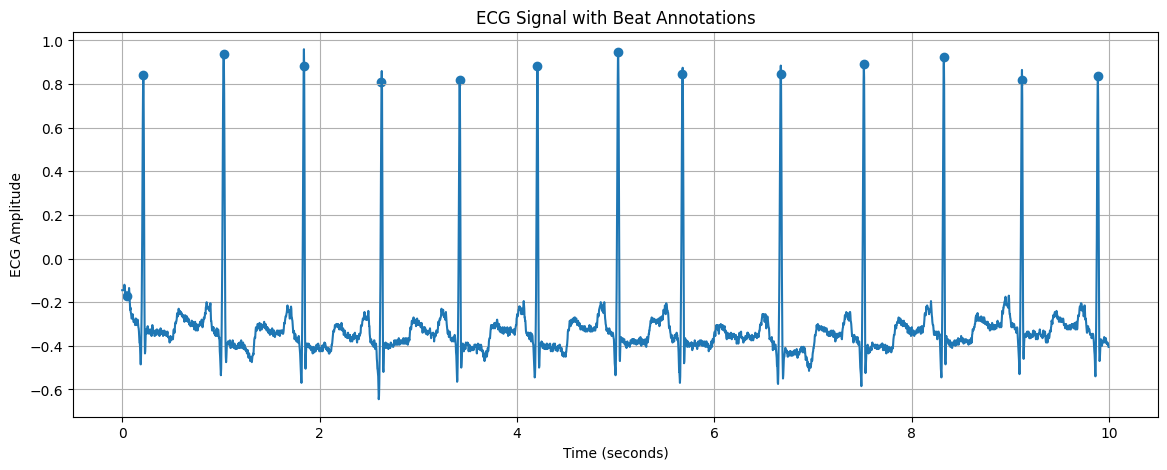

In [31]:
plt.figure(figsize=(14, 5))

plt.plot(time, signal)

# Select annotations within first 10 seconds
annotation_samples = annotation.sample[
    annotation.sample < samples
]

annotation_times = annotation_samples / sampling_frequency

annotation_values = record.p_signal[
    annotation_samples,
    0
]

plt.scatter(
    annotation_times,
    annotation_values
)

plt.title("ECG Signal with Beat Annotations")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")

plt.grid(True)

plt.show()

In [32]:
print("ECG Mean:", np.mean(signal))
print("ECG Maximum:", np.max(signal))
print("ECG Minimum:", np.min(signal))
print("ECG Standard Deviation:", np.std(signal))

ECG Mean: -0.31992222222222216
ECG Maximum: 0.96
ECG Minimum: -0.645
ECG Standard Deviation: 0.17022307930593625


In [33]:
beat_samples = annotation.sample[
    annotation.sample < samples
]

beat_times = beat_samples / sampling_frequency

number_of_beats = len(beat_times)

heart_rate = number_of_beats / seconds * 60

print("Approximate Heart Rate:", heart_rate, "BPM")

Approximate Heart Rate: 84.0 BPM


In [34]:
medical_data = pd.DataFrame({
    "Patient_ID": ["P001", "P002", "P003"],
    "Age": [45, 52, 38],
    "Heart_Rate": [82, 91, 74],
    "ECG_Available": [True, True, False],
    "Clinical_Note_Available": [True, True, True],
    "Medical_Image_Available": [True, False, True]
})

display(medical_data)

,Patient_ID,Age,Heart_Rate,ECG_Available,Clinical_Note_Available,Medical_Image_Available
0,P001,45,82,True,True,True
1,P002,52,91,True,True,False
2,P003,38,74,False,True,True


In [35]:
print("LAB EXPERIMENT 1 COMPLETED")

print("\nData Modalities Processed:")
print("1. Tabular Data - UCI Heart Disease Dataset")
print("2. Textual Data - Clinical Note")
print("3. Image Data - Medical Image")
print("4. Signal Data - MIT-BIH ECG")

print("\nLibraries Used:")
print("NumPy")
print("Pandas")
print("Matplotlib")
print("Pillow")
print("WFDB")
print("Scikit-learn")

LAB EXPERIMENT 1 COMPLETED

Data Modalities Processed:
1. Tabular Data - UCI Heart Disease Dataset
2. Textual Data - Clinical Note
3. Image Data - Medical Image
4. Signal Data - MIT-BIH ECG

Libraries Used:
NumPy
Pandas
Matplotlib
Pillow
WFDB
Scikit-learn
